# **Generate Dataset of sinthetic Argentinian DNIs**

Now that we have our backgrounds and our empty templates. In [00_draw_DNI_zones_v1](http://example.com) was defined the zones of the elements of Argentinian ID document. Then in [01_generate_sinthetic_example_v1](http://example.com) showed such as with `faker` is posible to generate a *fake* data to put on our template to simulate a real Argentina DNI.
Then in [02_backgrounds](http://example.com) was generated different backgrounds with *generative AI* and combine with photos that was taken by myself with a cellphone.

So, now the goal of this notebook is generate a *sinthetic dataset* to increase our *train* set to fine tunning a YOLO model for the task of ID Document detection. 

**Important information**

* All background images have a standard shape of 1024x1024px
* Shape of templates:
  
| x |DNI |Card |
|---------|-----|---------|
| Front    | 1445x920px   | 2513x1585px |
| Back     | 691x436px   | 2265x1458px |

* All cards (IDs, credit cards, driving licences) follow the international ID-1 standard. This standar demands an exactly size 
  * 85,60 mm *(width)*
  * 53.98 mm *(height)*
This means that the card is *58.5%* widther than height. And this allow known if is necessary to fit the width for example to a value of 500px, the height is calculated as a division of 500px/1,585 is aproximally 315px. And of this way the card is not disturbing

To do this, we will follow the next steps:

* Resize our templates to a width of approximately 500px and a height of approximately 315px without distorting the original images.
* Build a script to generate *fake* data and draw that information in their correct places with Pillow.

**Composition of the DNI with the background**

In this case, it doesn't work a simply *copy-paste* of our ID card on the background. 
To avoid this problem, is necessary to apply some computer vision techniques in this pipeline.
To achieve a combination between both realistics images, it will be necessary apply some layers of realism:
* **Perspective & Rotation:** never paste the DNI a 0º. Apply some random rotation between [-5º, 5ª] and a slight perspective warp.
* **Drop shadow:** without the shadow, the card simulate that is float in the background.
* **Others:** as a noise, Tone and Brightness Adjustment.

**Expected input:**
* ID Document templates for DNI and Card document types.
* Elements coordinates for each type of ID Document.
* Backgrounds.
* Fake data

**Expected output:**
* Synthetics images to increase our *training* set.

<p align="center">
  <img src="./assets/image.png" alt="Example" width="1200">
</p>

**Objective:**
* Generate around 300 synthetic examples to increase our dataset for this task.
## **Libraries and constants**


In [2]:
from faker import Faker
from PIL import Image, ImageOps, ImageDraw, ImageFont, ImageFilter
from datetime import datetime, timedelta
from typing import List, Tuple, Callable
from pprint import pprint
import os
import matplotlib.pyplot as plt
import random
import json

BACKGROUND_IMAGES_DIR = "../../data/prc/backgrounds_1024"
FACES_DATA = "../../data/Flickr-Faces-HQ"
TEMPLATES_DIR = "../../data/templates"
SYNTHETIC_DS_DIR = "../../data/prc/synthetic_ds"
ID_1_STANDARD_RATIO_ASPECT = 1.58  # Standard aspect ratio for ID cards (width / height)
TEMPLATES_NAMES = [
    "front_1.jpg",
    "front_2.jpg",
    "back_1.jpg",
    "back_2.jpg"
]

os.makedirs(SYNTHETIC_DS_DIR, exist_ok=True)

print(f"PIL version: {Image.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

PIL version: 12.3.0
Matplotlib version: 3.11.0


## **Resize templates**

In this step, we will resize our templates maintaining the original aspect ratio of the image and respecting de ID-1 Standard.

According to this standard, all cards have a width that is 58.5% greater than their height. Reduce the width of our templates to 500 px, and then paste them onto the backgrounds, which are 1024 x 1024 px.

* First define some functions to this task

In [2]:
def resize_image(image: Image, target_width: int = 500) -> Image:
    """Resize the image by its target width while maintaining aspect ratio.

    Args:
        image (Image): The image to resize.
        target_width (int, optional): The target width for the resized image. Defaults to 500.

    Returns:
        Image: The resized image.
    """
    # Calculate the target height based on the standard aspect ratio
    target_height = int(target_width / ID_1_STANDARD_RATIO_ASPECT)
    
    # Resize the image using the calculated dimensions
    resized_image = ImageOps.fit(image, (target_width, target_height), method=Image.LANCZOS)
    return resized_image

def resize_img_to_640x640(img: Image) -> Image:
    """Resize the image to 640x640 pixels.

    Args:
        img (Image): The image to resize.

    Returns:
        Image: The resized image.
    """
    return ImageOps.fit(img, (640, 640), method=Image.Resampling.LANCZOS)

## **Functions to show images**

In [3]:
def show(img: Image, title: str):
    plt.imshow(img)
    plt.title(title)
    plt.show()
    
def plot_images(images: list, labels: list):
    # Create subplots
    fig, ax = plt.subplots(1, len(images), figsize=(10, 5))

    for index, img in enumerate(images):
        # Show each image in subplot
        ax[index].imshow(img)
        ax[index].set_title(labels[index])
        ax[index].axis('off')

        fig.tight_layout()
    plt.show()

## **Fake generator data**

Define the functions with the logic to generate a *fake* data using `faker` library to put in our *fake* documents.

In [4]:
WEIGHTS = [7, 3, 1]
MIN_FAKE_DNI = 10_000_000
MAX_FAKE_DNI = 49_999_999
MIN_FAKE_TRAMITE = 10_000_000
MAX_FAKE_TRAMITE = 99_999_999
OFFICE_CODES = ["8504", "8420", "9874", "7430", "1234", "5678", "9012", "3456", "7890", "4321", "8765", "2109", "6543", "0987", "3210", "7654", "1098", "5432", "9876", "4321"]
NRO_OFFICE_CODES = len(OFFICE_CODES)
FACES_DATA = "../../data/Flickr-Faces-HQ"
DATES = [
    "30 JUN / JUN 1995",
    "12 ENE / JAN 1988",
    "05 FEB / FEB 2001",
    "18 MAR / MAR 1993",
    "27 ABR / APR 1986",
    "09 MAY / MAY 1998",
    "14 JUN / JUN 2004",
    "22 JUL / JUL 1991",
    "31 AGO / AUG 1984",
    "07 SEP / SEP 1997",
    "16 OCT / OCT 2000",
    "25 NOV / NOV 1992",
    "03 DIC / DEC 1989",
    "11 ENE / JAN 1996",
    "20 FEB / FEB 1983",
    "29 MAR / MAR 2002",
    "08 ABR / APR 1990",
    "17 MAY / MAY 1994",
    "26 JUL / JUL 1987",
    "13 DIC / DEC 1999",
]

def char_value(c):
    if c.isdigit():
        return int(c)
    elif c == "<":
        return 0
    elif c.isalpha():
        return ord(c.upper()) - ord("A") + 10  
    else:
        return 0

def checksum(field):
    total = sum(char_value(c) * WEIGHTS[i % 3] for i, c in enumerate(field))
    return str(total % 10)

def random_date(start_year, end_year):
    start = datetime(start_year, 1, 1)
    end = datetime(end_year, 12, 31)

    days = (end - start).days
    d = start + timedelta(days=random.randint(0, days))

    return d

def mrz_date(date):
    return date.strftime("%y%m%d")

def pad(text, length):
    text = text.upper().replace(" ", "<")
    return (text + "<" * length)[:length]

In [5]:
def generate_fake_name(fake: Faker) -> str:
    """ Generate a fake name with Faker library

    Args:
        fake (Faker): An instance of the Faker class

    Returns:
        str: A complete fake name (first and last name)
    """
    name = fake.name()
    if "." in name:
        name = name.split(".")[1].strip()
    return name

def generate_fake_address(fake: Faker) -> str:
    """Generate a fake address with Faker library"""
    return fake.address().replace("\n", " - ").upper()

def get_parts_of_name(name: str) -> tuple[str, str]:
    """ Splits a full name into first and last name parts"""
    parts = name.split(" ")
    if len(parts) == 2:
        return parts[0], parts[1]
    elif len(parts) == 3:
        return " ".join(parts[0:2]), parts[2]
    elif len(parts) == 4:
        return " ".join(parts[0:2]), " ".join(parts[2:4])
    elif len(parts) > 4:
        return " ".join(parts[0:2]), " ".join(parts[2:])
    else:
        raise ValueError(f"Name has unexpected number of parts: {name}")
    
def generate_fake_dni() -> str:
    """ Generates a fake DNI (Documento Nacional de Identidad) for Argentine IDs

    Returns:
        str: A fake DNI as a string
    """
    fake_dni = random.randint(MIN_FAKE_DNI, MAX_FAKE_DNI)
    fake_dni_str = str(fake_dni)

    if len(fake_dni_str) == 8:
        dni = fake_dni_str[0:2] + "." + fake_dni_str[2:5] + "." + fake_dni_str[5:8]

    if len(fake_dni_str) == 7:
        dni = fake_dni_str[0:1] + "." + fake_dni_str[1:4] + "." + fake_dni_str[4:7]
    return dni   
    
def generate_fake_tramite_number() -> str:
    """ Generates a fake 'numero de tramite' for Argentine IDs

    Returns:
        str: A fake 'numero de tramite' as a string prefixed with '00'
    """
    return "00" + str(random.randint(MIN_FAKE_TRAMITE, MAX_FAKE_TRAMITE))

def get_random_office_code() -> str:
    """ Returns a random office code.

    Returns:
        str: A random office code
    """
    return random.choice(OFFICE_CODES)

def generate_fake_mrz(document: str,
                      first_name: str,
                      last_name: str,):
    """ Generates a fake MRZ (Machine Readable Zone) for an Argentine ID following
    the ICAO 9303(TD1) standard. The MRZ consists of three lines, with 30 characters each.

    Args:
        document (str): _description_
        first_name (str): _description_
        last_name (str): _description_

    Returns:
        str: The generated MRZ as a string with three lines.
    """
    document = document.replace(".", "")
    dock_check = checksum(document)
    
    birth_date = random_date(1950, 2010)
    birth_date_str = mrz_date(birth_date)
    birth_date_check = checksum(birth_date_str)
    
    expiration_date = random_date(2027, 2037)
    expiration_date_str = mrz_date(expiration_date)
    expiration_date_check = checksum(expiration_date_str)
    
    sex = random.choice(["M", "F"])
    
    # Line 1
    line1 = ("I<" + "ARG" + document + dock_check)
    line1 = pad(line1, 30)
    
    # Line 2
    optional = "<" * 11
    partial = (birth_date_str + birth_date_check + sex + expiration_date_str + expiration_date_check + "ARG" + optional)
    final_check = checksum(document + dock_check + birth_date_str + birth_date_check + expiration_date_str + expiration_date_check)

    line2 = pad(partial + final_check, 30)

    # Line 3
    line3 = pad(f"{last_name}<<{first_name}", 30)
    
    return line1 + "\n" + line2 + "\n" + line3

In [6]:
def to_fixed(img: Image, coords: List[List[float]]) -> List[List[int]]:
    """  Converts relative coordinates to absolute pixel coordinates based on the image size.

    Args:
        img (Image): The PIL Image object.
        coords (List[List[float]]): A list of relative coordinates (as fractions of the image dimensions).

        
    Returns:
        List[List[int]]: A list of absolute pixel coordinates.
    """
    return [[int(a * img.size[0]), int(b * img.size[1])] for a, b in coords] 


def draw_text_with_spacing(draw: ImageDraw,
                           text: str,
                           position: List[int],
                           font: ImageFont,
                           fill: tuple[int, int, int],
                           spacing: int):
    """Draw text with custom spacing between characters.

    Args:
        draw (ImageDraw): _description_
        text (str): _description_
        position (List[int]): _description_
        font (ImageFont): _description_
        fill (tuple[int, int, int]): _description_
        spacing (int): _description_
    """
    x,y = position
    for char in text:
        draw.text((x, y), char, fill=fill, font=font)
        char_width = font.getbbox(char)[2] - font.getbbox(char)[0]
        x += char_width + spacing

def draw_field(draw: ImageDraw,
               text: str,
               position: List[int],
               font: ImageFont,
               fill: tuple[int, int, int, int]):
    """Draw text in an specific position on the image.

    Args:
        draw (ImageDraw): _description_
        text (str): _description_
        position (List[int]): _description_
        font (ImageFont): _description_
        fill (tuple[int, int, int, int]): _description_
    """
    draw.text(position, text, fill=fill, font=font)

def paste_synthetic_dni(img: Image) -> Tuple[Image, float]:
    """ Paste a syntetic DNI onto a background image."""
    bg_name = random.choice(os.listdir(BACKGROUND_IMAGES_DIR))
    bg_img = Image.open(os.path.join(BACKGROUND_IMAGES_DIR, bg_name)).convert("RGBA")

    # Random rotation between -5 and 5 degrees
    angle = random.uniform(-5, 5)
    img_rot = img.rotate(
        angle,
        resample=Image.Resampling.BICUBIC,
        expand=True,
        fillcolor=(0, 0, 0, 0) # transparent
    )

    # Center
    x = (bg_img.width - img_rot.width) // 2
    y = (bg_img.height - img_rot.height) // 2

    # Paste respecting alpha
    out = bg_img.copy()

    # Drop shadow
    shadow = Image.new("RGBA", img_rot.size, (0, 0, 0, 0))
    alpha = img_rot.split()[3]
    shadow.paste((0, 0, 0, 120), (0, 0), alpha)  # shadow opacity
    shadow = shadow.filter(ImageFilter.GaussianBlur(radius=6))

    out.paste(shadow, (x, y), shadow)

    # Paste card
    out.paste(img_rot, (x, y), img_rot)

    return out, angle

def choose_and_paste_picture(img: Image, coords: list) -> Image:
    """Choose and paste a random face image onto the given image at the specified coordinates."""
    # Select a random face image from the FACES_DATA directory
    face_image_choice = random.choice(os.listdir(FACES_DATA))
    face_image_path = os.path.join(FACES_DATA, face_image_choice)
    face_img = Image.open(face_image_path).convert("RGBA")

    absolute_coords = to_fixed(img, coords)
    x1, y1 = absolute_coords[0]
    x2, y2 = absolute_coords[1]
    target_w, target_h = x2 - x1, y2 - y1
    # Resize the face image + Center crop to fit the target area
    face_img_a = ImageOps.fit(image=face_img.copy(),
                            size=(target_w, target_h),
                            method=Image.Resampling.LANCZOS,
                            centering=(0.5, 0.5))
    # Paste the face image onto the DNI template
    # img.paste(face_img, (x1, y1))
    alpha = face_img_a.split()[3].point(lambda a: int(a * 0.8))
    face_img_a.putalpha(alpha)
    img.paste(face_img_a, (x1, y1), face_img_a)
    return img


In [7]:
def complete_dni_data(front: Image, 
                      back: Image, 
                      user: str,
                      coords: dict,
                      fake: Faker) -> Tuple[Image, Image]:
    font_bold = ImageFont.truetype("../../fonts/arial.ttf", size=34)
    font_document_number = ImageFont.truetype("../../fonts/Arial Bold.ttf", size=66)
    font = ImageFont.truetype("../../fonts/arial.ttf", size=15)
    ocrb_font = ImageFont.truetype("../../fonts/ocrb.ttf", size=40)
    fill = (20, 20, 20, 205)  # RGBA color for text

    front_draw = ImageDraw.Draw(front)
    back_draw = ImageDraw.Draw(back)

    ## Front data insertion
    # First name 
    first_name, last_name = get_parts_of_name(user)
    absolute_coords = to_fixed(front, coords['front']['FIRST_NAME_COORD'])
    draw_field(draw=front_draw,
            text=first_name.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=fill)

    # Last name
    absolute_coords = to_fixed(front, coords['front']['LAST_NAME_COORD'])
    draw_field(draw=front_draw,
            text=last_name.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=fill)

    # Sex
    absolute_coords = to_fixed(front, coords['front']['SEX_COORD'])
    draw_field(draw=front_draw,
            text=random.choice(["M", "F"]),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=fill)

    # Nationality
    absolute_coords = to_fixed(front, coords['front']['NATIONALITY_COORD'])
    draw_field(draw=front_draw,
            text="ARGENTINA",
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=fill)

    # Birth Date
    absolute_coords = to_fixed(front, coords['front']['BIRTH_DATE_COORD'])
    draw_field(draw=front_draw,
            text=random.choice(DATES),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=fill)

    # Document number
    document_number = generate_fake_dni()
    absolute_coords = to_fixed(front, coords['front']['DOCUMENT_NUMBER_COORD'])
    draw_field(draw=front_draw,
            text=document_number,
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_document_number,
            fill=(20, 20, 20))

    # Tramite number
    tramite_number = generate_fake_tramite_number()
    absolute_coords = to_fixed(front, coords['front']['NRO_TRAMITE_COORD'])
    draw_text_with_spacing(draw=front_draw,
                        text=tramite_number,
                        position=(absolute_coords[0][0], absolute_coords[0][1]),
                        font=font_bold,
                        fill=fill,
                        spacing=3
    )

    # Office code
    office_code = get_random_office_code()
    absolute_coords = to_fixed(front, coords['front']['OFFICE_CODE_COORD'])
    draw_text_with_spacing(draw=front_draw,
                        text=office_code,
                        position=(absolute_coords[0][0], absolute_coords[0][1]),
                        font=font_bold,
                        fill=fill,
                        spacing=2
    )

    ## Back data insertion
    # Address
    address = generate_fake_address(fake)
    absolute_coords = to_fixed(back, coords['back']['ADDRESS_COORD'])
    draw_field(draw=back_draw,
            text=address.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font,
            fill=fill)

    # MRZ (Machine Readable Zone)
    mrz = generate_fake_mrz(document_number, first_name, last_name)
    absolute_coords = to_fixed(back, coords['back']['MRZ_COORD'])
    draw_field(draw=back_draw,
            text=mrz,
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=ocrb_font,
            fill=fill)
    
    ## Image Face insertion
    front = choose_and_paste_picture(front, coords['front']['PICTURE_COORD'])
    return front, back

In [8]:
def complete_card_data(front: Image, 
                      back: Image, 
                      user: str,
                      coords: dict,
                      fake: Faker) -> Tuple[Image, Image]:
    font = ImageFont.truetype("../../fonts/arial.ttf", size=66)
    font_bold = ImageFont.truetype("../../fonts/Arial Bold.ttf", size=66)
    ocrb_font = ImageFont.truetype("../../fonts/ocrb.ttf", size=130)

    front_draw = ImageDraw.Draw(front)
    back_draw = ImageDraw.Draw(back) 

    fill = (20, 20, 20, 205)  # RGBA color for text
    ## Front data insertion
    # First name
    first_name, last_name = get_parts_of_name(user)
    absolute_coords = to_fixed(front, coords['front']['LAST_NAME_COORD'])
    draw_field(draw=front_draw,
            text=first_name.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font,
            fill=fill)

    # Last name
    absolute_coords = to_fixed(front, coords['front']['FIRST_NAME_COORD'])
    draw_field(draw=front_draw,
            text=last_name.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font,
            fill=fill)

    # Document number
    document_number = generate_fake_dni()
    absolute_coords = to_fixed(front, coords['front']['DOCUMENT_NUMBER_COORD'])
    draw_field(draw=front_draw,
            text=document_number,
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font_bold,
            fill=(20, 20, 20))

    # Sex
    absolute_coords = to_fixed(front, coords['front']['SEX_COORD'])
    draw_field(draw=front_draw,
            text=random.choice(["M", "F"]),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font,
            fill=fill)

    mrz = generate_fake_mrz(document_number, first_name, last_name)
    absolute_coords = to_fixed(front, coords['front']['MRZ_COORD'])
    draw_field(draw=front_draw,
            text=mrz,
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=ocrb_font,
            fill=fill)

    ## Back data insertion
    # Address
    address = generate_fake_address(fake)
    absolute_coords = to_fixed(back, coords['back']['ADDRESS_COORD'])
    draw_field(draw=back_draw,
            text=address.upper(),
            position=(absolute_coords[0][0], absolute_coords[0][1]),
            font=font,
            fill=fill)

    # Tramite Number
    tramite_number = generate_fake_tramite_number()
    absolute_coords = to_fixed(back, coords['back']['NRO_TRAMITE_COORD'])
    draw_text_with_spacing(draw=back_draw,
                        text=tramite_number,
                        position=(absolute_coords[0][0], absolute_coords[0][1]),
                        font=font,
                        fill=fill,  
                        spacing=4
    )

    ## Image Face insertion
    front = choose_and_paste_picture(front, coords['front']['PICTURE_COORD'])
    return front, back

In [9]:
with open('./config/coords_data.json', 'r', encoding='utf-8') as json_data:
    coords_data = json.load(json_data)

pprint(coords_data)

{'card': {'back': {'ADDRESS_COORD': [[0.16997792494481237, 0.08916323731138547],
                                     [0.6181015452538632, 0.12345679012345678]],
                   'COUNTRY_COORD': [[0.3598233995584989, 0.6310013717421125],
                                     [0.45474613686534215, 0.8916323731138546]],
                   'NRO_TRAMITE_COORD': [[0.06622516556291391,
                                          0.6742112482853223],
                                         [0.25165562913907286,
                                          0.7133058984910837]]},
          'front': {'DOCUMENT_NUMBER_COORD': [[0.043772383605252686,
                                               0.39936908517350156],
                                              [0.31834460803820136,
                                               0.4416403785488959]],
                    'FIRST_NAME_COORD': [[0.043772383605252686,
                                          0.23659305993690852],
                     

In [10]:
def generate_synthetic_ds(fake: Faker,
                          front_path: str,
                          back_path: str,
                          count: int,
                          total_examples: int,
                          complete_data_fn: Callable[[Image, Image, str, dict, Faker], Tuple[Image, Image]],
                          doc_type: str = "dni",
                          target_width: int = 500):
    """Generate a synthetic dataset of ID cards"""
    for i in range(total_examples):
        user = generate_fake_name(fake)
        front = Image.open(front_path).convert("RGBA")
        back = Image.open(back_path).convert("RGBA")
        front, back = complete_data_fn(front, back, user, coords_data[doc_type], fake)
        front, _ = paste_synthetic_dni(img=resize_image(front, target_width=target_width))
        back, _ = paste_synthetic_dni(img=resize_image(back, target_width=target_width))
        front = resize_img_to_640x640(front)
        back = resize_img_to_640x640(back)
        front.save(os.path.join(SYNTHETIC_DS_DIR, f"{count}.png"))
        back.save(os.path.join(SYNTHETIC_DS_DIR, f"{count+1}.png"))
        count += 2
    print(f"Generated {total_examples} synthetic {doc_type.upper()} examples in {SYNTHETIC_DS_DIR}")

## Generate Synthetic Dataset of ID Documents**

In this step we will generate our *synthetic* dataset of ID document of *dni* and *card* types.

Generate 250 examples of *DNIS* and 100 examples of *Card*.

Show some examples.

In [12]:
fake = Faker("es_AR")

In [17]:
COUNT = len(os.listdir(SYNTHETIC_DS_DIR))
COUNT = COUNT if COUNT > 0 else 2000

generate_synthetic_ds(fake=fake,
                      front_path=os.path.join(TEMPLATES_DIR, "front_1.jpg"),
                      back_path=os.path.join(TEMPLATES_DIR, "back_1.jpg"),
                      count=COUNT,
                      total_examples=250,
                      complete_data_fn=complete_dni_data,
                      doc_type="dni",
                      target_width=750)                       

Generated 250 synthetic DNI examples in ../../data/prc/synthetic_ds


In [18]:
COUNT = len(os.listdir(SYNTHETIC_DS_DIR))
COUNT = COUNT + 2000 if COUNT > 0 else 2000

generate_synthetic_ds(fake=fake,
                      front_path=os.path.join(TEMPLATES_DIR, "front_2.jpg"),
                      back_path=os.path.join(TEMPLATES_DIR, "back_2.jpg"),
                      count=COUNT,
                      total_examples=80,
                      complete_data_fn=complete_card_data,
                      doc_type="card",
                      target_width=750)            

Generated 80 synthetic CARD examples in ../../data/prc/synthetic_ds


* Show somes examples of sythetics documents generated previously

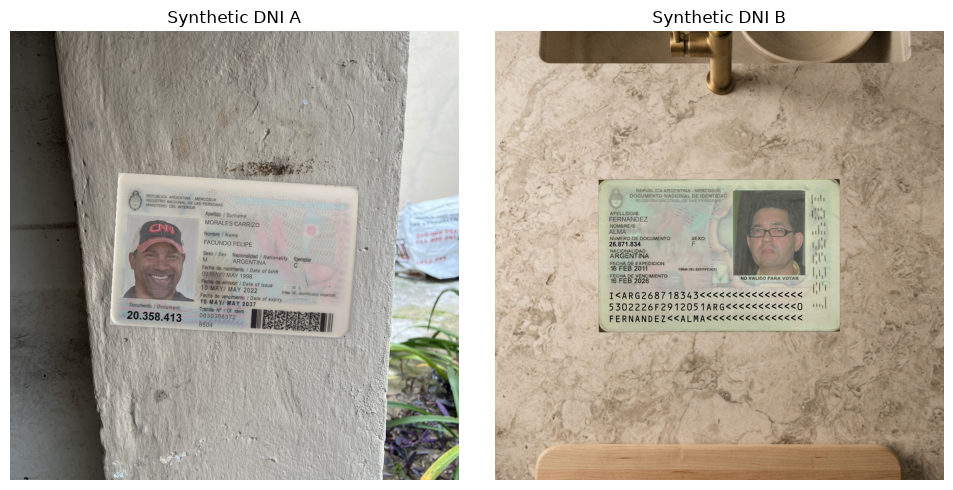

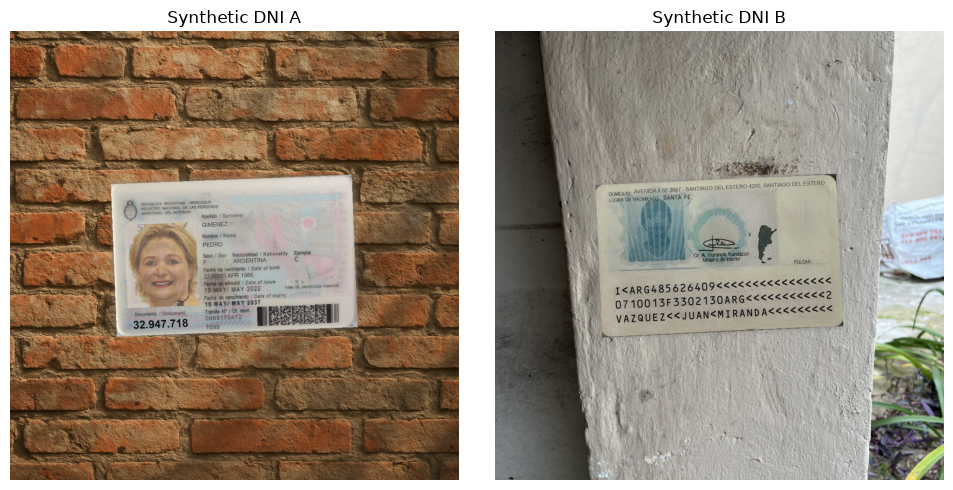

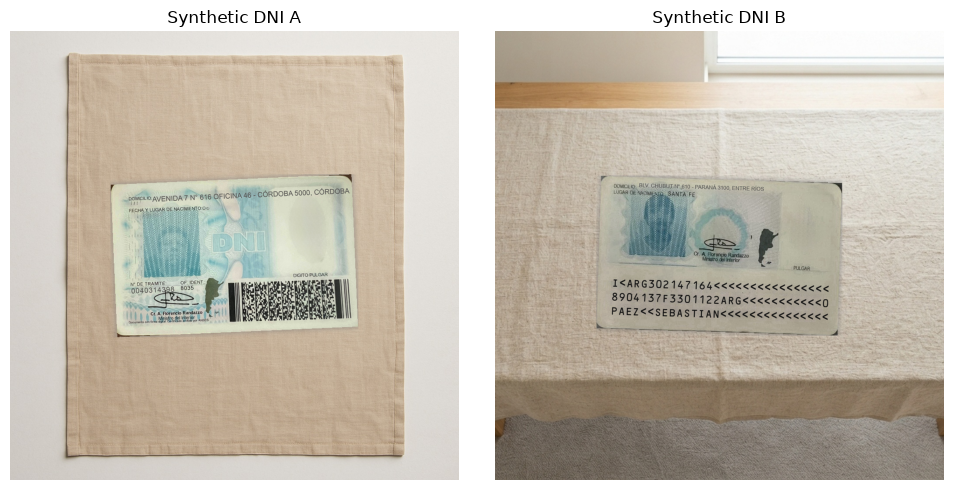

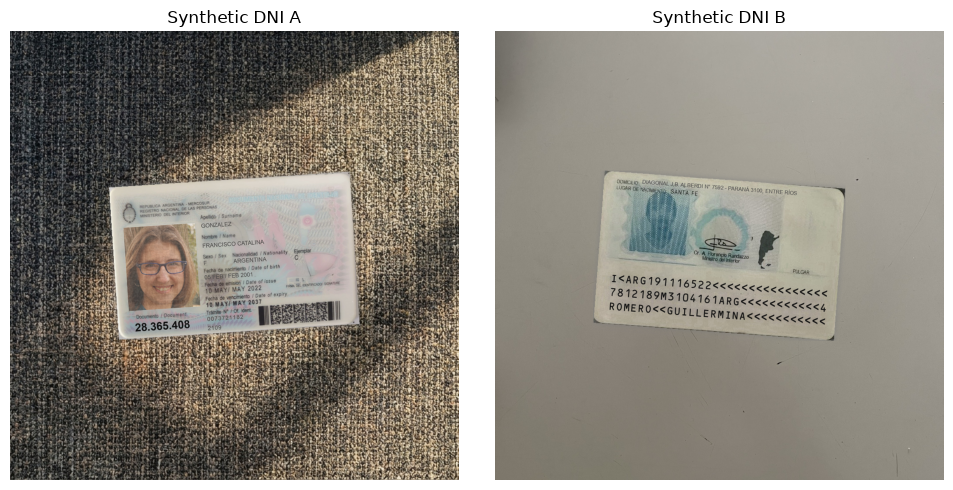

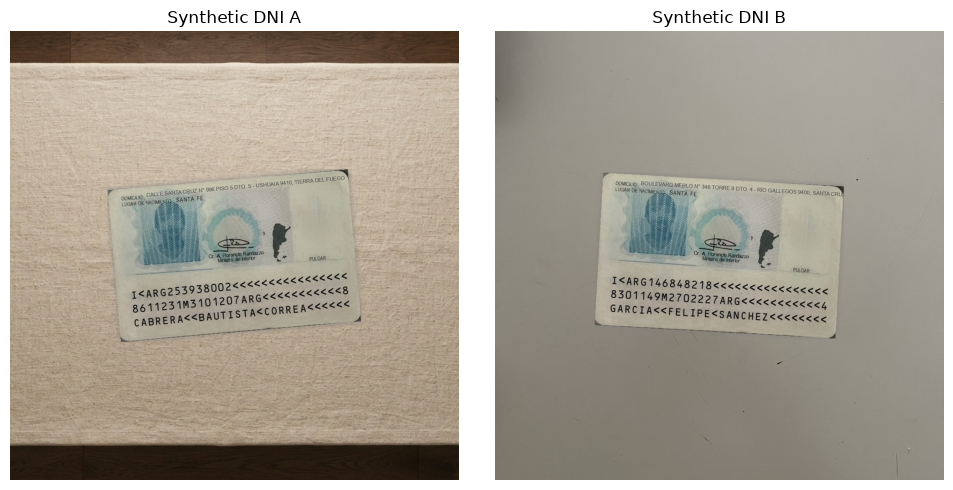

In [ ]:
for i in range(5):
    img_a = Image.open(
        os.path.join(SYNTHETIC_DS_DIR, random.choice(os.listdir(SYNTHETIC_DS_DIR))))
    img_b = Image.open(
        os.path.join(SYNTHETIC_DS_DIR, random.choice(os.listdir(SYNTHETIC_DS_DIR))))
    plot_images([img_a, img_b], ["Synthetic DNI A", "Synthetic DNI B"])